In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
cm_number = 10
cm = plt.cm.get_cmap("tab10")
colors = [cm(1. / (cm_number - 1) * i) for i in range(0, cm_number)]
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset, zoomed_inset_axes
mpl.rc('font', family='Arial')
mpl.rc('font',size = 6)
mpl.rc('mathtext',fontset = 'stix')
mpl.rc('xtick', labelsize=4)
mpl.rc('ytick', labelsize=4)
# mpl.rc('xtick', labelsize=4)
# mpl.rc('ytick', labelsize=4)
mpl.rc('axes', labelsize=6)
mpl.rc('axes', labelpad=1)
mpl.rc('axes', titlesize=6)
mpl.rc('axes', linewidth=0.5)
figsavepath = "../../Elements/Numerical"

In [2]:
Fs = 100
T = 400
t = np.linspace(0,T,T*Fs)
omega0 = 2
omega1 = 2

Amplitude_F = 1 # Forcing Amplitude
damping = 5e-2
damping2 = 1e-2
cubic = 1e-3
coupling = 1e-2
Modes = 2

def POD_like(x,t, Omega):
    u1, v1, u2, v2 = x
    du1 = v1
    dv1 = (-omega0**2)*u1-damping*v1-cubic*u1**3+Amplitude_F*np.cos(Omega*t)
    du2 = v2
    dv2 = -omega1**2*u2-damping2*v2-coupling*u1**2
    return [du1, dv1, du2, dv2]


x0 = [0,0,0,0]
Omega = 2.02
F = np.cos(Omega*t)
x = odeint(POD_like, x0, t, args = (Omega,))

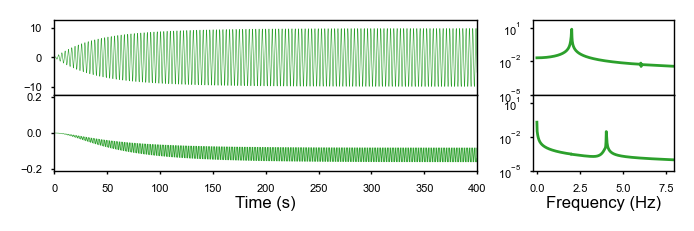

In [3]:
fig, axes = plt.subplots(Modes,2,figsize = (4,Modes*0.5),  gridspec_kw={'width_ratios': [3, 1]},dpi = 200)
plt.subplots_adjust(hspace = 0)
for mode in range(Modes):
    ax = axes[mode][0]
    if mode != Modes-1:
        axes[mode][0].set_xticks([])
        axes[mode][1].set_xticks([])
    else:
        axes[mode][0].set_xlabel("Time (s)")
        axes[mode][1].set_xlabel("Frequency (Hz)")
    y = x[:,mode*2]
    ax.plot(t,y,color = colors[2],lw = 0.2)
    ax.tick_params(direction='out',width = 0.5,length = 1)
    ax.set_xlim(0,t[-1])
    ax.set_ylim(-np.max(np.abs(y))*1.3,np.max(np.abs(y))*1.3)
    ax = axes[mode][1]
    N = len(y)
    yf = fft(y)
    xf = fftfreq(N, (t[-1]-t[0])/N)[:N//2]
    ax.plot(xf*2*np.pi, 2.0/N * np.abs(yf[0:N//2]),color = colors[2], lw = 1)
    # ax.set_xlim(-0.02,2)
    ax.set_yscale('log')
    ax.tick_params(direction='out',width = 0.5,length = 1)
    ax.set_ylim(0.00001,50)
    ax.set_xlim(-0.2,8)

In [4]:
import importlib
import sys
sys.path.append("../")
import EvLOWN
importlib.reload(EvLOWN)  # 重新载入
library = [
    lambda x:x[0],
    lambda x:x[0]*x[0],
    lambda x:x[0]*x[0]*x[0],
    lambda x:x[1],
    lambda x:x[1]*x[1],
    lambda x:x[1]*x[1]*x[1],
    lambda x:x[2],
    lambda x:x[2]*x[2],
    lambda x:x[2]*x[2]*x[2],
    lambda x:x[3],
    lambda x:x[3]*x[3],
    lambda x:x[3]*x[3]*x[3],
    # lambda x:x[0]*x[1],
    # lambda x:x[0]*x[2],
    # lambda x:x[0]*x[3],
    # lambda x:x[0]*x[0]*x[1],
    # lambda x:x[0]*x[1]*x[1],
    
]
library_name = [
    lambda x:x[0],
    lambda x:x[0]+x[0],
    lambda x:x[0]+x[0]+x[0],
    lambda x:x[1],
    lambda x:x[1]+x[1],
    lambda x:x[1]+x[1]+x[1],
    lambda x:x[0]+x[1],
    lambda x:x[0]+x[0]+x[1],
    lambda x:x[0]+x[1]+x[1],
]
dim = 2
model = EvLOWN.WeakNOForce(dim,library,library_name)

In [5]:

# Xis = np.zeros([len(library)+1,Modes])
model = EvLOWN.WeakNOForce(dim,library,library_name)
model.Get_frequency(x[:,[0,2]],x[:,[1,3]],t)
model.frequencys[1] = model.frequencys[0]
print(model.frequencys)
model.Get_Evolution(order = [0,1,2])
model.Library_rebuild(F[:])
T_period = 2*np.pi/model.frequencys[0]
num_period = int((t[-1] - t[0]) // T_period)
t_periods = np.linspace(0,T, num_period+1)

[2.01329945 2.01329945]


In [11]:
orders = [[1,2],[0,3,4]]
model.optimize(orders = orders, startcycle = 1, endcycle=10,sparse_threshold=1e-1, stop_tolerance=0.1)

C:\ProgramData\Anaconda3\lib\site-packages\scs\__init__.py:111: UserWarning: Converting A to a CSC (compressed sparse column) matrix; may take a while.
  warn(
C:\ProgramData\Anaconda3\lib\site-packages\scs\__init__.py:141: UserWarning: Converting P to a CSC (compressed sparse column) matrix; may take a while.
  warn(


start:3.53965
Round 0, step: 0.07442, now: 0.92558, selected: 12
Round 1, step: 0.46210, now: 0.46347, selected: 3
Round 2, step: 0.19194, now: 0.27153, selected: 2
Round 3, step: 0.25606, now: 0.01547, selected: 0
start:6.47989
Round 0, step: 0.98250, now: 0.01750, selected: 1


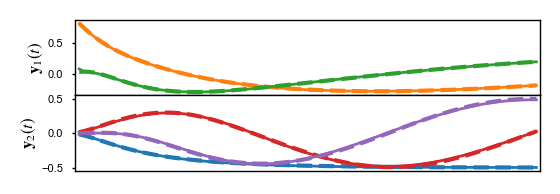

In [7]:
stp = 1
enp = 10
Modes = 2
Omegaidxs = [0,6]
Xis = np.zeros([len(library)+1, Modes])
fig, axes = plt.subplots(Modes,1,figsize = (3,Modes*0.5),dpi = 200)
plt.subplots_adjust(hspace = 0)
ylims = [(-0.27,0.27),(-0.0016,0.0016),(-0.007,0.007),(-0.007,0.007)]
legends = ['$y^{(0)}$','$y^{(1,\cos)}$','$y^{(1,\sin)}$','$y^{(2,\cos)}$','$y^{(2,\sin)}$']
for d in range(Modes):
    Xi = model.Xi[d]
    Xis[:,d] = Xi
    Xis[Omegaidxs[d],d] +=model.frequencys[0]**2
    # for d in range(3):
    #     ax = axes[d]
    ax = axes[d]
    ax.set_xlabel('Time')
    if d!=2:
        ax.set_xticks([])
        ax.set_xlabel("")
    ax.set_xlim(0,t_periods[-1-enp])
    # ax.set_ylim(ylims[d])
    ax.set_ylabel(r'$\mathbf{y}_%d(t)$'%(d+1))
    ax.tick_params(direction='out',width = 0.5,length = 1)
    
    for i in orders[d]:
        ax.plot(t_periods[stp:-enp-1],model.dot[d][stp:-enp,i],color = colors[i],lw = 1)
        ax.plot(t_periods[stp:-enp-1],np.sum(model.Phi[d][stp:-enp,i,:]*Xi, axis = 1),color = colors[i],ls = '--',lw = 1.5)

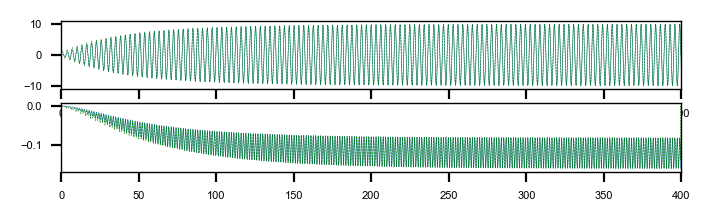

In [8]:
slow_variables = np.zeros([2,len(t),5])
for d in range(2):
    for j in range(5):
        for i in range(num_period):
            slow_variables[d,int(T_period*i*Fs):int((T_period*(i+1))*Fs),j] = model.evolutions[d][i,j]
fig, axes = plt.subplots(2,1,figsize = (4,Modes*0.5),dpi = 200)
bases = [np.ones_like(t),np.cos(model.frequencys[0]*t),np.sin(model.frequencys[0]*t),np.cos(2*model.frequencys[0]*t),np.sin(2*model.frequencys[0]*t)]
orders = [[1,2],[0,3,4]]
for d in range(2):
    ax = axes[d]
    ax.plot(t,x[:,d*2], lw = 0.2)
    approx = np.zeros_like(t)
    for j in orders[d]:
        approx+=bases[j]*slow_variables[d,:,j]
    ax.plot(t,approx,lw = 0.2, ls = '--',color = 'green')
    # ax.plot(t,approx - x[:,d*2],lw = 0.2, ls = '--',color = 'green')
    ax.set_xlim(0,400)

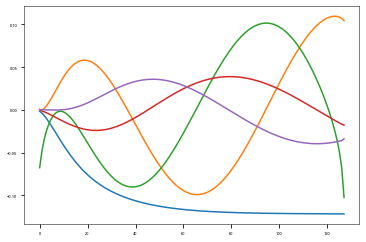

In [9]:
for i in range(5):
    plt.plot(model.evolutions[1][:,i])

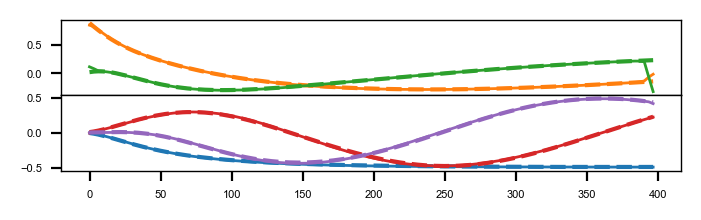

In [10]:
Coef = [
    [
    omega0**2-model.frequencys[0]**2, 0, cubic,
    damping,0 , 0,
    0, 0, 0, 
    0, 0, 0,
    -Amplitude_F
    ],
    [
    0, coupling, 0,
    0, 0, 0,
    omega1**2-model.frequencys[1]**2, 0, 0, 
    0, 0, 0,
    0
    ]
]
fig, axes = plt.subplots(2,1,figsize = (4,Modes*0.5),dpi = 200)
plt.subplots_adjust(hspace = 0)
t_labels = ["$y^{(0)}(t)$", r"$y^{(1,\cos)}(t)$",r"$y^{(1,\sin)}(t)$",r"$y^{(2,\cos)}(t)$",r"$y^{2,\sin}(t)$"]
d = 1
for d in range(2):
    ax = axes[d]
    for i in orders[d]:
        ax.plot(t_periods[:-1],model.dot[d][:,i],color = colors[i],lw = 1, label = t_labels[i])
        ax.plot(t_periods[:-1],np.sum(model.Phi[d][:,i,:]*Coef[d], axis = 1),color = colors[i],ls = '--',lw = 1.5)

In [823]:
# Check multi-task least square method
stp = 0
enp = 1
Effect_idxs = [
    [0,2,3,6,12],
    [1,6]
]
omega0s = [omega0, omega1]
for d in range(2):
    print(omega0s[d]**2-model.frequencys[d]**2)
    print(
        EvLOWN.Xi(
            model.dot[d][stp:-enp,orders[d]],
            model.Phi[d][stp:-enp,orders[d],:],
            Effect_idxs[d]
        )
    )

-0.05337467680095909
[-4.42716686e-02  0.00000000e+00  8.29396548e-04  4.66509494e-02
  0.00000000e+00  0.00000000e+00 -1.88329650e+01  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
 -9.45429785e-01]
-0.05337467680095909
[ 0.          0.01003386  0.          0.          0.          0.
 -0.06946989  0.          0.          0.          0.          0.
  0.        ]


In [824]:
# Predict responses
# def 


In [826]:
# Check the OMP
d = 0
stp = 10
enp = 10
EvLOWN.OMP(
    model.dot[d][stp:-enp,orders[d]],
    model.Phi[d][stp:-enp,orders[d],:],
    scale = np.ones(len(library)),
    sparse_threshold=1e-2,
    step_tolerance=1e-2
)

0.12444361854596753
0.8755563814540326
0.09529328315042758
0.029150335395539944
0.02283110644353735
0.07246217670689024
0.00531037535387803
0.01752073108965932
4.447817461725053e-05
0.00526589717926078
[4.25487351e-02 0.00000000e+00 4.90238794e-02 2.00000000e+00
 0.00000000e+00 5.87608231e-05 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 1.99093938e+00]


array([-5.40828559e-02,  0.00000000e+00,  1.01122657e-03,  5.06233061e-02,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
       -1.01224643e+00])

In [678]:
# Predict FRF
